In [7]:
# 导入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 正常显示负号


In [8]:
#导入数据
campaigns = pd.read_csv('campaigns.csv')
customers = pd.read_csv('customers.csv')
events = pd.read_csv('events.csv')
products = pd.read_csv('products.csv')
transactions = pd.read_csv('transactions.csv')


In [17]:
#处理缺失值
campaigns.isnull().sum()
customers.isnull().sum()
# bounce行为不涉及具体商品
events['product_id'] = events['product_id'].fillna('no_product')
# 对比有无device_type两组的事件类型分布，查看缺失值是否是异常访问造成的损失
events['device_missing'] = events['device_type'].isna()
events.groupby('device_missing')['event_type'].value_counts(normalize=True)
events['device_type'] = events['device_type'].fillna('unknown')
events.isnull().sum()
products.isnull().sum()
transactions.isnull().sum()
# 删除 product_id 为空的交易记录，剔除无效订单
transactions = transactions.dropna(subset=['product_id'])

#处理重复值
campaigns.duplicated().sum()
customers.duplicated().sum()
events.duplicated().sum()
products.duplicated().sum()
transactions.duplicated().sum()

#处理异常值
# 标记年龄异常
customers = customers[(customers['age'] >= 10) & (customers['age'] <= 120)]
products = products[products['base_price'] >= 0]
events = events[events['session_duration_sec'] >= 0]
transactions = transactions[(transactions['quantity'] > 0) & (transactions['gross_revenue'] >= 0)]


Index(['campaign_id', 'channel', 'objective', 'start_date', 'end_date',
       'target_segment', 'expected_uplift'],
      dtype='str')


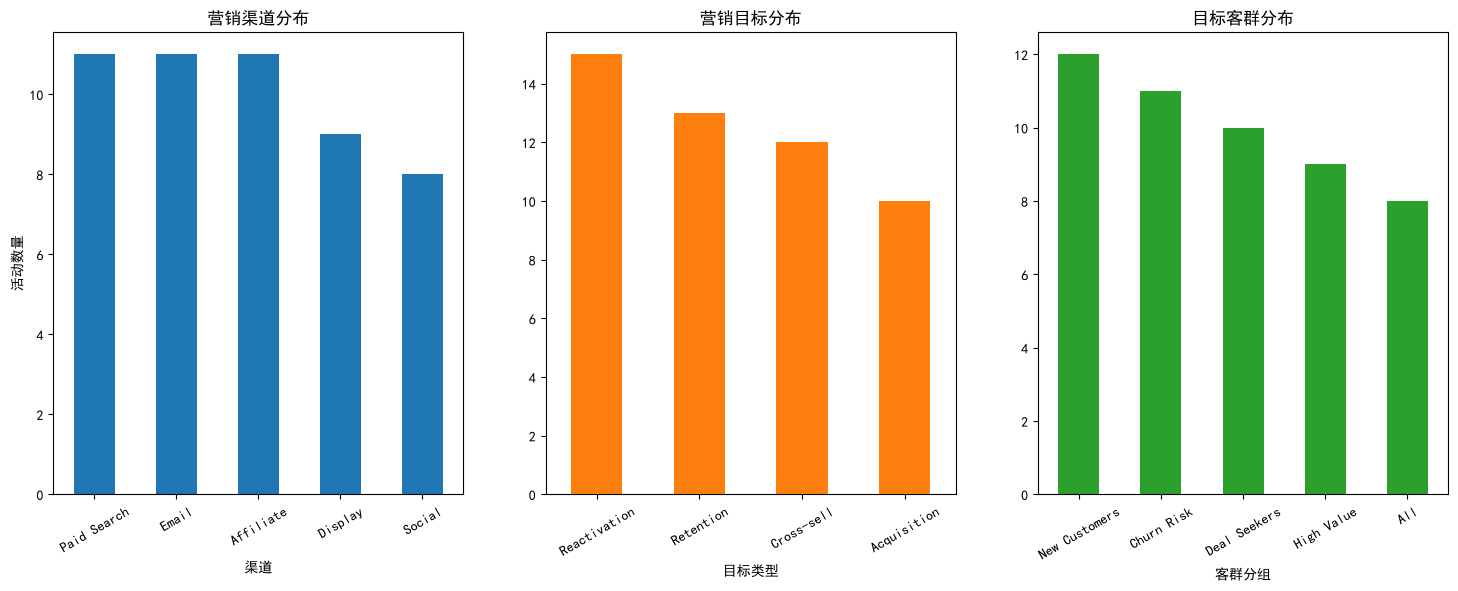

In [10]:
#EDA
print(campaigns.columns)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
campaigns['channel'].value_counts().plot(kind='bar',ax=axes[0],color="#1f77b4")
#channel渠道分布
axes[0].set_title('营销渠道分布')
axes[0].set_xlabel('渠道')
axes[0].set_ylabel('活动数量')
axes[0].tick_params(axis='x', rotation=30)
#objective营销目标分布
campaigns['objective'].value_counts().plot(kind='bar', ax=axes[1], color="#ff7f0e")
axes[1].set_title('营销目标分布')
axes[1].set_xlabel('目标类型')
axes[1].tick_params(axis='x', rotation=30)
#target_segment目标人群分布
campaigns['target_segment'].value_counts().plot(kind='bar', ax=axes[2], color="#2ca02c")
axes[2].set_title('目标客群分布')
axes[2].set_xlabel('客群分组')
axes[2].tick_params(axis='x', rotation=30)


Index(['customer_id', 'signup_date', 'country', 'age', 'gender',
       'loyalty_tier', 'acquisition_channel'],
      dtype='str')
loyalty_tier
Bronze      60276
Silver      24912
Gold        11794
Platinum     3018
Name: count, dtype: int64
acquisition_channel
Organic        30200
Paid Search    29950
Social         14979
Email          14903
Referral        9968
Name: count, dtype: int64


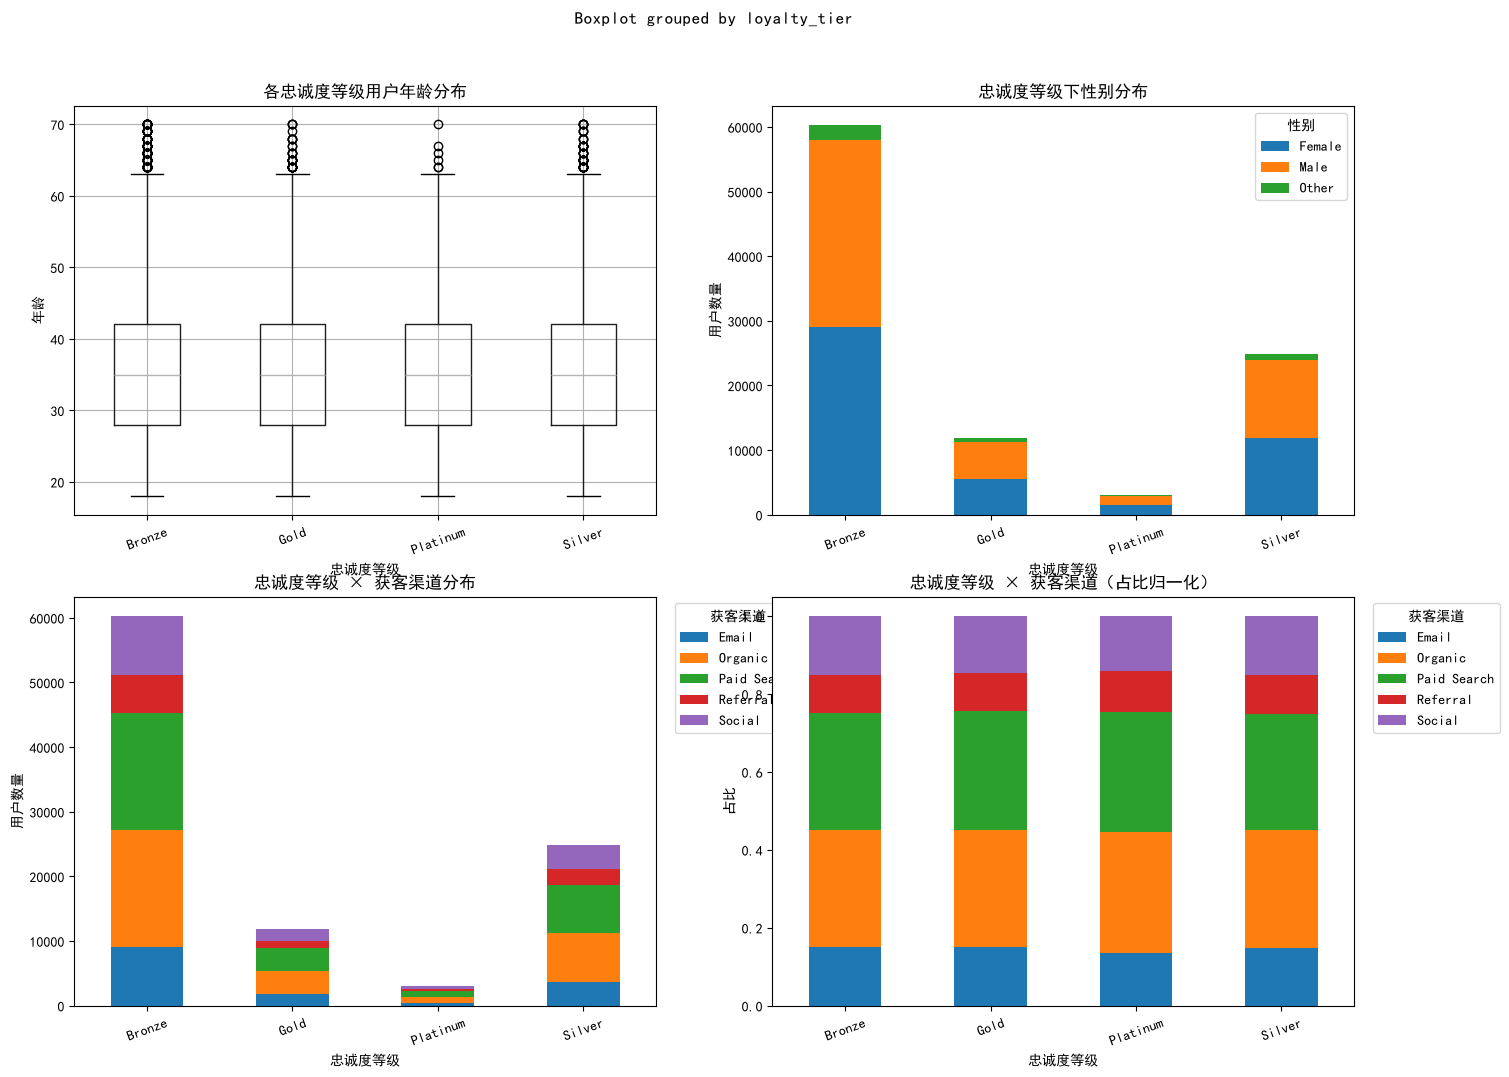

In [11]:
#Customers
print(customers.columns)
# 查看忠诚度、获客渠道分布
print(customers['loyalty_tier'].value_counts())
print(customers['acquisition_channel'].value_counts())

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
#忠诚度--年龄箱线图
customers.boxplot(column='age', by='loyalty_tier', ax=axes[0,0])
axes[0,0].set_title('各忠诚度等级用户年龄分布')
axes[0,0].set_xlabel('忠诚度等级')
axes[0,0].set_ylabel('年龄')
axes[0,0].tick_params(axis='x', rotation=20)
#忠诚度--性别柱状图
gender_cross = pd.crosstab(customers['loyalty_tier'], customers['gender'])
gender_cross.plot(kind='bar', stacked=True, ax=axes[0,1])
axes[0,1].set_title('忠诚度等级下性别分布')
axes[0,1].set_xlabel('忠诚度等级')
axes[0,1].set_ylabel('用户数量')
axes[0,1].legend(title="性别")
axes[0,1].tick_params(axis='x', rotation=20)
#忠诚度--获客渠道柱状图
channel_cross = pd.crosstab(customers['loyalty_tier'], customers['acquisition_channel'])
channel_cross.plot(kind='bar', stacked=True, ax=axes[1,0])
axes[1,0].set_title('忠诚度等级 × 获客渠道分布')
axes[1,0].set_xlabel('忠诚度等级')
axes[1,0].set_ylabel('用户数量')
axes[1,0].legend(title="获客渠道", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1,0].tick_params(axis='x', rotation=20)
#渠道占比归一化
channel_cross_norm = pd.crosstab(customers['loyalty_tier'], customers['acquisition_channel'], normalize='index')
channel_cross_norm.plot(kind='bar', stacked=True, ax=axes[1,1])
axes[1,1].set_title('忠诚度等级 × 获客渠道（占比归一化）')
axes[1,1].set_xlabel('忠诚度等级')
axes[1,1].set_ylabel('占比')
axes[1,1].legend(title="获客渠道", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1,1].tick_params(axis='x', rotation=20)

Index(['event_id', 'timestamp', 'customer_id', 'session_id', 'event_type',
       'product_id', 'device_type', 'traffic_source', 'campaign_id',
       'page_category', 'session_duration_sec', 'experiment_group',
       'device_missing'],
      dtype='str')


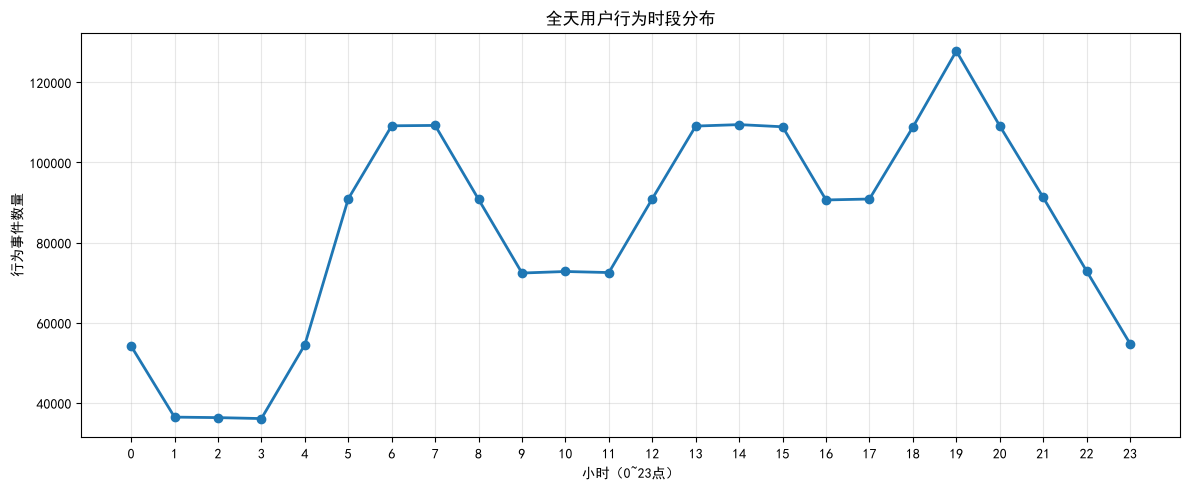

In [12]:
#Columns
print(events.columns)
events['timestamp'] = pd.to_datetime(events['timestamp'])
events['hour'] = events['timestamp'].dt.hour
#统计每个小时的行为数量
hour_count = events['hour'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
hour_count.plot(kind='line', marker='o', color='#1f77b4', linewidth=2)
plt.title('全天用户行为时段分布')
plt.xlabel('小时（0~23点）')
plt.ylabel('行为事件数量')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
print(products.columns)
print(transactions.columns)

Index(['product_id', 'category', 'brand', 'base_price', 'launch_date',
       'is_premium'],
      dtype='str')
Index(['transaction_id', 'timestamp', 'customer_id', 'product_id', 'quantity',
       'discount_applied', 'gross_revenue', 'campaign_id', 'refund_flag'],
      dtype='str')


In [18]:

events.to_csv("events_clean.csv", index=False, encoding="utf-8-sig")
customers.to_csv("customers_clean.csv", index=False, encoding="utf-8-sig")
transactions.to_csv("transactions_clean.csv", index=False, encoding="utf-8-sig")
campaigns.to_csv("campaigns_clean.csv", index=False, encoding="utf-8-sig")
products.to_csv("products_clean.csv", index=False, encoding="utf-8-sig")


In [6]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

# 使用 localhost 替代计算机名
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"  # 改用 localhost
    "DATABASE=e-commerce;"
    "Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(conn_str)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

df = pd.read_csv('products_clean.csv', encoding='utf-8')

df.to_sql(
    name='products',
    con=engine,
    if_exists='append',
    index=False,
)

print('导入完成')

导入完成


In [14]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

# 使用 localhost 替代计算机名
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"  # 改用 localhost
    "DATABASE=e-commerce;"
    "Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(conn_str)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

sql = 'select * from dbo.user_type_revenue'
df = pd.read_sql(sql,engine)
df.to_csv(
    'user_type_revenue.csv',
    index=False,
    encoding = 'utf-8-sig'
)

print('导出完成')

导出完成
